# Tanaos Topic Classification

#### Project Overview

The goal of this project is to build and compare Natural Language Processing (NLP) classifiers for a multiclass topic classification task.

In this notebook, we will:

- understand the dataset and its characteristics;
- perform exploratory data analysis (EDA);
- preprocess the text data;
- build feature representations such as Bag-of-Words and TF-IDF;
- train baseline and stronger traditional machine learning classifiers;
- evaluate the models using suitable metrics;
- analyze the most common classification errors.

This project follows the assignment constraints, meaning that only traditional machine learning methods are used, and no deep learning architectures such as CNNs, RNNs, or Transformers are applied.

## Imports

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score, f1_score

import numpy as np

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

## Load Dataset

In this section, we load the training dataset and inspect its basic structure.  
The goal is to understand:

- how many examples are available;
- which columns exist;
- how labels are stored;
- whether there are missing values;
- whether the dataset appears balanced across classes.

In [2]:
df = pd.read_csv("data/train_data.csv")

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (10232, 2)

Columns:
['text', 'labels']

Data types:
text      object
labels     int64
dtype: object

Missing values:
text      0
labels    0
dtype: int64


In [4]:
df.head()

,text,labels
0,The rise of populist movements has reshaped gl...,0
1,A balanced diet rich in fruits and vegetables ...,1
2,Quantum cryptography is revolutionizing secure...,2
3,Streaming platforms have transformed how audie...,3
4,Crypto investors are diversifying portfolios a...,4


In [5]:
topics = ["politics","health","technology","entertainment","money_finance","relationships_dating","education_learning","work_careers","science","society_culture","gaming","lifestyle_hobbies","sports","automotive","other"]

### Label Mapping

The dataset stores class labels numerically, so we define a dictionary that maps each numeric label to its corresponding topic name.

In [6]:
topic_dict = dict(enumerate(topics))
print(topic_dict)

{0: 'politics', 1: 'health', 2: 'technology', 3: 'entertainment', 4: 'money_finance', 5: 'relationships_dating', 6: 'education_learning', 7: 'work_careers', 8: 'science', 9: 'society_culture', 10: 'gaming', 11: 'lifestyle_hobbies', 12: 'sports', 13: 'automotive', 14: 'other'}


In [7]:
print("Columns:", df.columns.tolist())
print("Unique labels:", sorted(df["labels"].unique()))
print("Number of classes:", df["labels"].nunique())

Columns: ['text', 'labels']
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]
Number of classes: 15


## Preprocessing Strategy

Before training any classifier, the text is normalized in order to reduce noise and make the feature extraction more consistent.

The preprocessing steps used here are:

- removal of non-alphabetic characters;
- conversion to lowercase;
- tokenization by whitespace splitting;
- stopword removal;
- stemming with PorterStemmer.

A small exception is made for negation-related words, since removing them may discard useful meaning.

## Cleanup and normalization


In [8]:
negations_to_keep = {
    "no", "nor", "not", "ain", "aren", "aren't", "couldn", "couldn't", "didn", "didn't",
    "doesn", "doesn't", "hadn", "hadn't", "hasn", "hasn't", "haven", "haven't", "isn",
    "isn't", "mightn", "mightn't", "mustn", "mustn't", "needn", "needn't", "shan",
    "shan't", "shouldn", "shouldn't", "wasn", "wasn't", "weren", "weren't", "won",
    "won't", "wouldn", "wouldn't"
}

In [9]:
corpus = []
ps = PorterStemmer()
sw = set(stopwords.words('english'))
sw = sw-negations_to_keep
for i in range(0, df['text'].size):
    # get review and remove non alpha chars
    review = re.sub('[^a-zA-Z]', ' ', df['text'][i])
    # to lower-case
    review = review.lower()
    # split into tokens, apply stemming and remove stop words
    review = ' '.join([ps.stem(w) for w in review.split() if w not in sw])
    corpus.append(review)

print("Number of processed documents:", len(corpus))
print("\nExample original text:")
print(df['text'].iloc[0])

print("\nExample processed text:")
print(corpus[0])

Number of processed documents: 10232

Example original text:
The rise of populist movements has reshaped global political landscapes.

Example processed text:
rise populist movement reshap global polit landscap


In [10]:
df["processed_text"] = corpus
df.head()

,text,labels,processed_text
0,The rise of populist movements has reshaped gl...,0,rise populist movement reshap global polit lan...
1,A balanced diet rich in fruits and vegetables ...,1,balanc diet rich fruit veget support long term...
2,Quantum cryptography is revolutionizing secure...,2,quantum cryptographi revolution secur commun m...
3,Streaming platforms have transformed how audie...,3,stream platform transform audienc consum tv co...
4,Crypto investors are diversifying portfolios a...,4,crypto investor diversifi portfolio amid marke...


## EDA

In this section, we explore the dataset before training models.

The main goals are:

- inspect class balance;
- inspect text length distributions;
- visualize common words;
- better understand the difficulty of the classification problem.


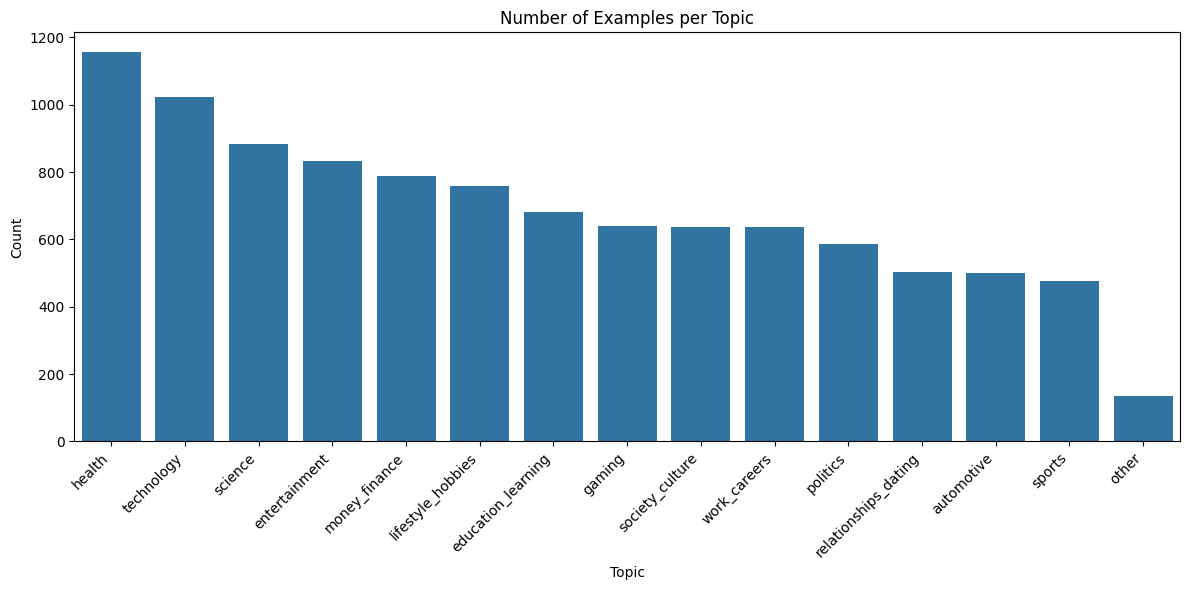

labels
health                  1157
technology              1023
science                  883
entertainment            833
money_finance            788
lifestyle_hobbies        758
education_learning       680
gaming                   639
society_culture          638
work_careers             637
politics                 585
relationships_dating     503
automotive               499
sports                   475
other                    134
Name: count, dtype: int64


In [11]:
mapped_counts = df["labels"].map(topic_dict).value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=mapped_counts.index, y=mapped_counts.values)
plt.title("Number of Examples per Topic")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(mapped_counts)

### Text Length Analysis

Another useful characteristic is the length of the texts.  
This helps determine whether the dataset contains short snippets, medium-length documents, or longer samples, and whether there is strong variation between classes.

In [12]:
df["text_length_chars"] = df["text"].astype(str).apply(len)
df["text_length_words"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print(df[["text_length_chars", "text_length_words"]].describe())

       text_length_chars  text_length_words
count       10232.000000       10232.000000
mean          117.031274          16.935301
std            33.527611           5.239986
min            27.000000           3.000000
25%            93.000000          13.000000
50%           113.000000          16.000000
75%           136.000000          20.000000
max           374.000000          57.000000


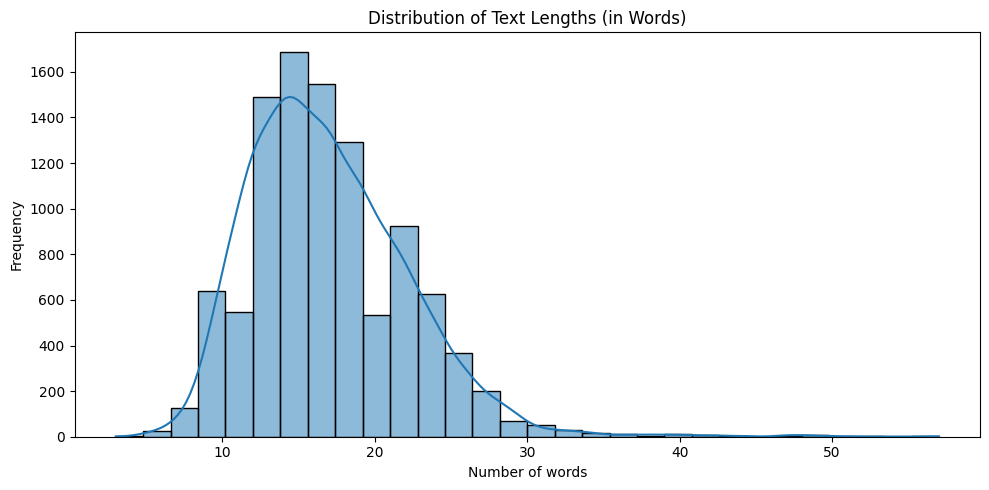

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df["text_length_words"], bins=30, kde=True)
plt.title("Distribution of Text Lengths (in Words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

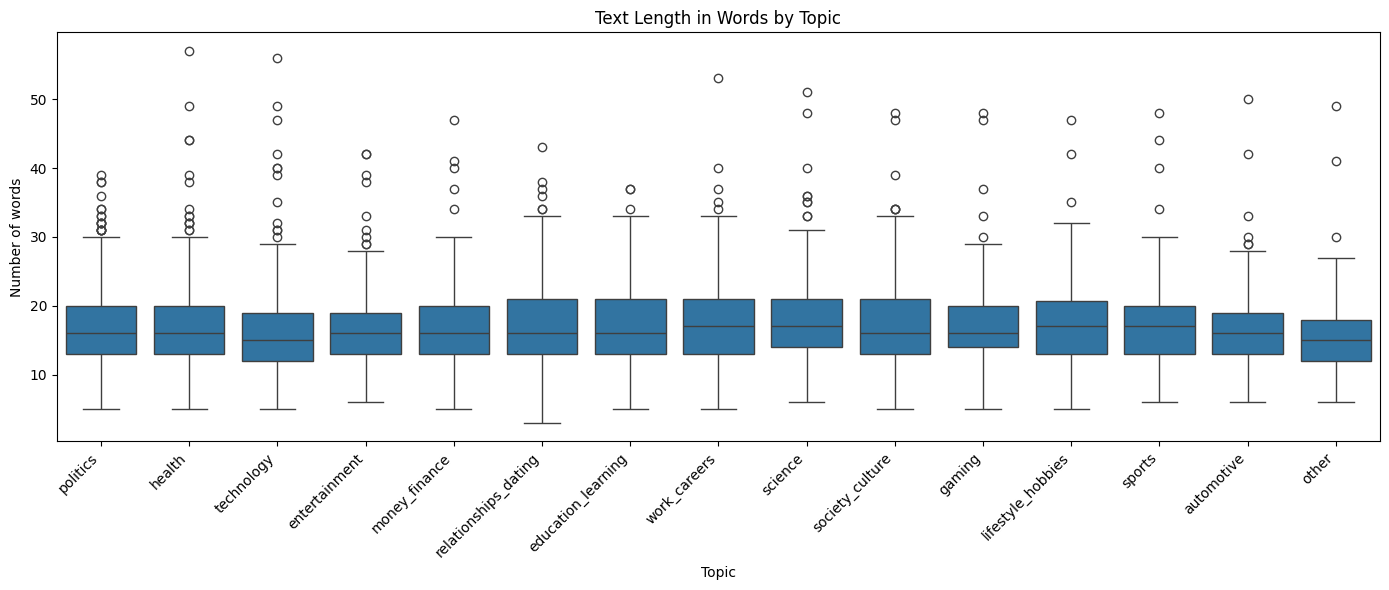

In [14]:
plt.figure(figsize=(14, 6))
sns.boxplot(x=df['labels'].map(topic_dict), y=df["text_length_words"])
plt.title("Text Length in Words by Topic")
plt.xlabel("Topic")
plt.ylabel("Number of words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Global Word Cloud

A word cloud provides a quick visual overview of the most frequent terms in the processed corpus.  
Although it is not a rigorous analysis by itself, it helps identify dominant vocabulary patterns.

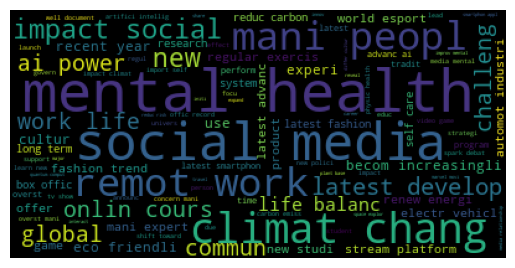

In [15]:
wordcloud = WordCloud().generate(" ".join(corpus))

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

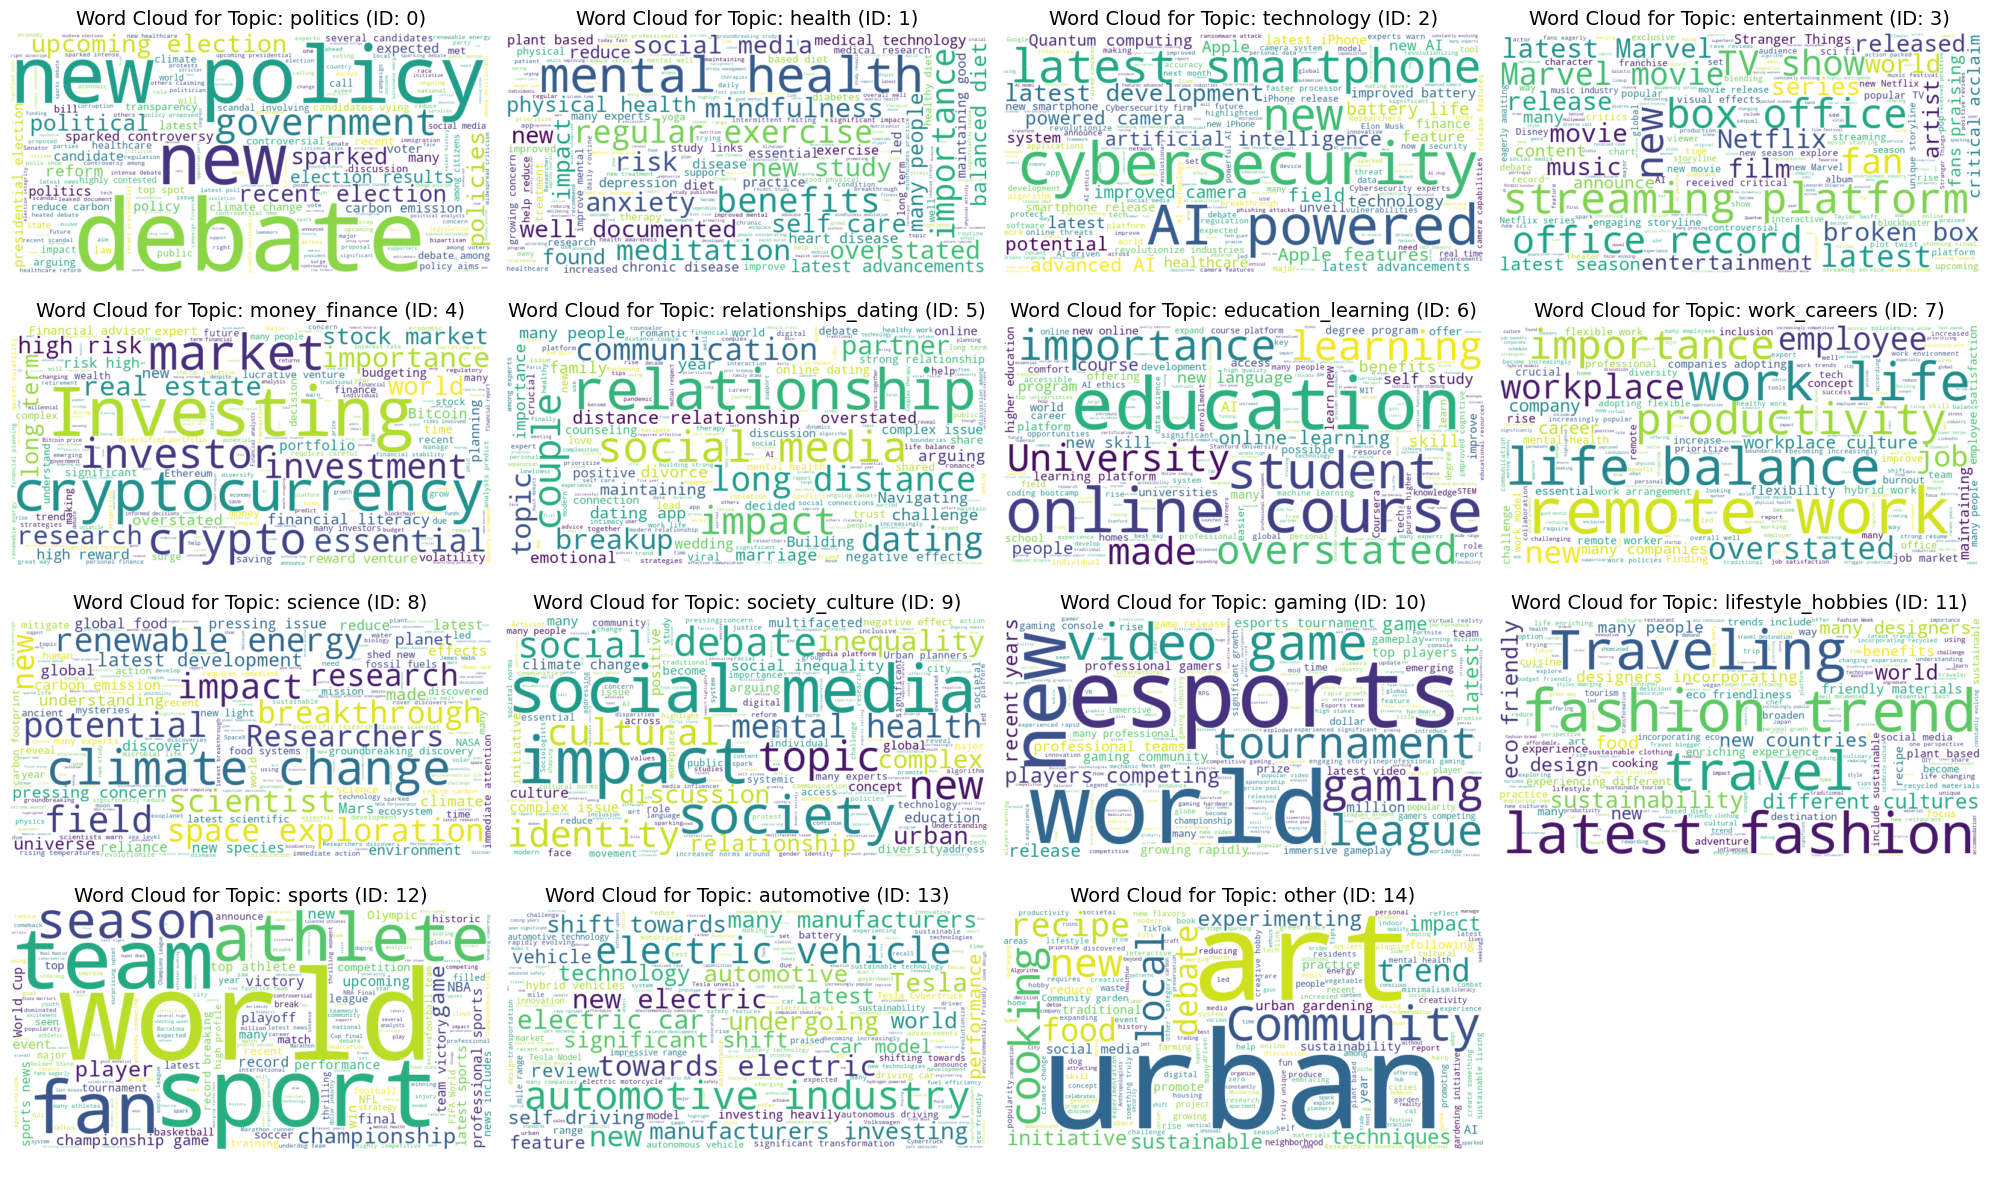

In [16]:
num_rows = (len(topic_dict) + 3) // 4
fig, axes = plt.subplots(num_rows, 4, figsize=(20, 3 * num_rows))
axes = axes.flatten()

for i, (label_id, topic_name) in enumerate(topic_dict.items()):

    topic_corpus_data = df[df["labels"] == label_id]["text"]

    topic_corpus_string = " ".join(topic_corpus_data.dropna())

    if topic_corpus_string.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(topic_corpus_string)

        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(f"Word Cloud for Topic: {topic_name} (ID: {label_id})", fontsize=14)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"No Text for {topic_name}", ha='center', va='center')
        axes[i].axis('off')

for j in range(i + 1, num_rows * 4):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Most Frequent Words in the Whole Corpus

To complement the word clouds, we also inspect the most frequent tokens directly.  
This gives a clearer view of the vocabulary that dominates the dataset after preprocessing.

In [17]:
all_words = " ".join(df["processed_text"]).split()
word_freq = Counter(all_words)

top_words = pd.DataFrame(word_freq.most_common(20), columns=["word", "count"])
top_words

,word,count
0,new,1989
1,latest,1265
2,mani,1050
3,world,812
4,health,792
5,work,672
6,ai,665
7,mental,646
8,social,602
9,impact,598


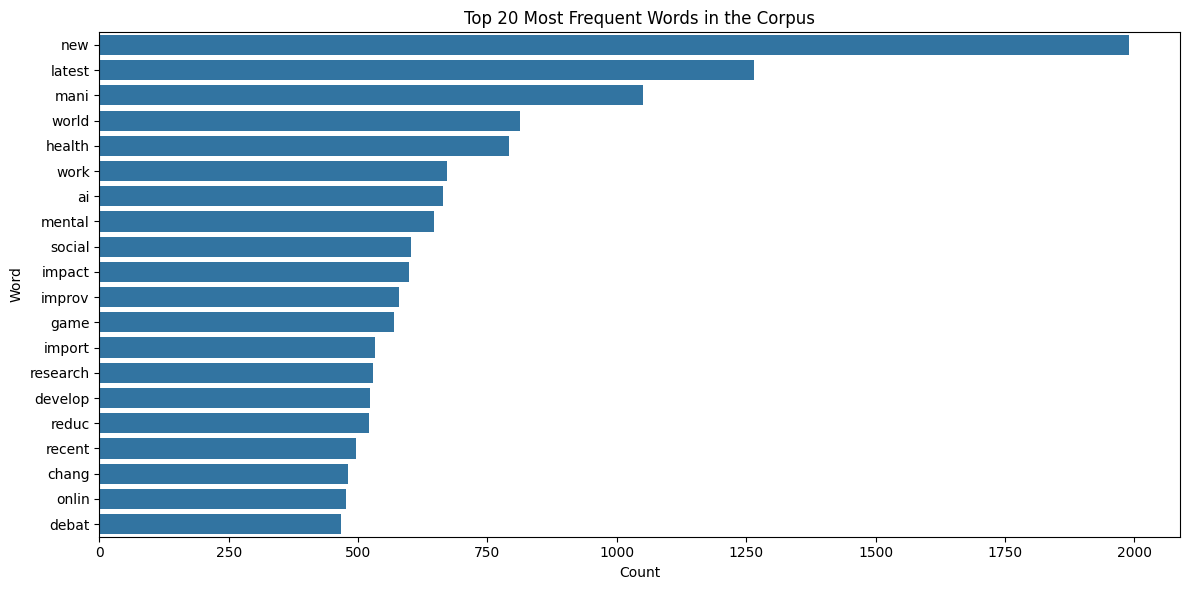

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x="count", y="word")
plt.title("Top 20 Most Frequent Words in the Corpus")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

### Most Frequent Words by Topic

Since this is a topic classification task, it is useful to inspect which words are most common within each class.  
This may reveal whether some topics are easier to distinguish due to more specific vocabulary.

In [19]:
top_n = 10

for label_id, topic_name in topic_dict.items():
    topic_words = " ".join(df[df["labels"] == label_id]["processed_text"]).split()
    topic_counter = Counter(topic_words)
    topic_top = pd.DataFrame(topic_counter.most_common(top_n), columns=["word", "count"])
    
    print(f"\nTop words for topic: {topic_name}")
    display(topic_top)


Top words for topic: politics


,word,count
0,elect,230
1,polici,210
2,debat,181
3,new,159
4,spark,145
5,recent,116
6,controversi,109
7,polit,98
8,candid,86
9,upcom,82



Top words for topic: health


,word,count
0,health,609
1,mental,483
2,new,222
3,diet,207
4,reduc,206
5,improv,205
6,studi,204
7,well,178
8,exercis,176
9,benefit,158



Top words for topic: technology


,word,count
0,ai,394
1,latest,343
2,cybersecur,240
3,new,232
4,featur,181
5,advanc,179
6,power,176
7,smartphon,169
8,camera,165
9,develop,151



Top words for topic: entertainment


,word,count
0,movi,226
1,new,214
2,latest,200
3,stream,187
4,fan,157
5,platform,149
6,releas,135
7,record,134
8,marvel,115
9,box,114



Top words for topic: money_finance


,word,count
0,invest,305
1,market,218
2,financi,195
3,cryptocurr,184
4,investor,150
5,risk,135
6,crypto,117
7,high,117
8,stock,99
9,financ,82



Top words for topic: relationships_dating


,word,count
0,relationship,272
1,social,130
2,date,128
3,media,106
4,coupl,104
5,impact,84
6,long,78
7,commun,67
8,distanc,64
9,year,53



Top words for topic: education_learning


,word,count
0,onlin,314
1,learn,284
2,educ,261
3,cours,250
4,new,186
5,univers,164
6,student,120
7,platform,107
8,skill,105
9,offer,92



Top words for topic: work_careers


,word,count
0,work,532
1,remot,290
2,balanc,158
3,life,156
4,compani,143
5,employe,141
6,product,133
7,job,125
8,workplac,122
9,mani,110



Top words for topic: science


,word,count
0,climat,280
1,new,227
2,research,218
3,chang,216
4,latest,176
5,space,125
6,potenti,119
7,discoveri,119
8,energi,119
9,scientist,115



Top words for topic: society_culture


,word,count
0,social,244
1,media,167
2,impact,165
3,cultur,129
4,societi,121
5,inequ,115
6,complex,78
7,mani,77
8,debat,75
9,issu,74



Top words for topic: gaming


,word,count
0,game,448
1,esport,259
2,world,221
3,tournament,174
4,player,150
5,new,146
6,profession,124
7,compet,111
8,team,109
9,latest,106



Top words for topic: lifestyle_hobbies


,word,count
0,travel,298
1,fashion,212
2,sustain,199
3,new,195
4,trend,192
5,friendli,151
6,cultur,147
7,mani,143
8,eco,140
9,latest,140



Top words for topic: sports


,word,count
0,sport,196
1,world,146
2,team,145
3,athlet,125
4,championship,84
5,game,76
6,victori,67
7,fan,62
8,final,62
9,latest,55



Top words for topic: automotive


,word,count
0,electr,302
1,vehicl,211
2,automot,209
3,industri,148
4,car,146
5,new,142
6,technolog,114
7,tesla,112
8,model,104
9,signific,88



Top words for topic: other


,word,count
0,urban,30
1,commun,28
2,garden,20
3,art,19
4,sustain,17
5,cook,15
6,new,15
7,initi,13
8,creativ,12
9,local,12


## Pre-processing and Feature Representation

In this first baseline, we use a sparse Bag-of-Words representation with `CountVectorizer`.

This means each document is represented by a vector of token counts, where:

- each feature corresponds to a vocabulary term;
- the value indicates how many times that term appears in the document.

This is a simple and standard baseline for text classification.

In [20]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

print("Feature matrix shape:", X.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Feature matrix shape: (10232, 5673)
Vocabulary size: 5673


In [21]:
feature_names = vectorizer.get_feature_names_out()

print("First 100 features:")
print(feature_names[:100])

First 100 features:
['aaa' 'abandon' 'abel' 'abil' 'abl' 'abnorm' 'abort' 'abroad' 'abruptli'
 'absolut' 'abstract' 'abu' 'abuzz' 'acacia' 'academ' 'academi' 'academia'
 'acceler' 'accept' 'access' 'accessori' 'accid' 'acclaim' 'accommod'
 'accomplish' 'accord' 'account' 'accountablil' 'accredit' 'accumul'
 'accur' 'accuraci' 'accus' 'acestop' 'achiev' 'acidifi' 'acknowledg'
 'acl' 'acoust' 'acquir' 'acquisit' 'across' 'acsm' 'act' 'action' 'activ'
 'activist' 'actor' 'actress' 'actual' 'ad' 'adapt' 'add' 'addict' 'addit'
 'address' 'adjust' 'administr' 'admiss' 'adob' 'adolesc' 'adopt'
 'adrenalin' 'adriana' 'adult' 'adulthood' 'advanc' 'advantag' 'advent'
 'adventur' 'advers' 'advertis' 'advic' 'advis' 'advisor' 'advisori'
 'advoc' 'advocaci' 'aerial' 'aerob' 'aerodynam' 'aerospac' 'aesthet'
 'affair' 'affect' 'affirm' 'afford' 'afloat' 'africa' 'african'
 'afrobeat' 'aftermath' 'age' 'agenc' 'agenda' 'agent' 'aggreg' 'aggress'
 'ago' 'agoni']


In [22]:
y = df['labels']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10232, 5673)
y shape: (10232,)


## Split Dataset

The dataset is split into training and test sets.

A stratified split is used so that the label distribution remains approximately the same in both sets.  
This is important in multiclass classification, especially if some classes are less frequent than others.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

print("\nLabel distribution in the training set:")
print(y_train.value_counts().sort_index())

print("\nLabel distribution in the test set:")
print(y_test.value_counts().sort_index())

(8185, 5673) (8185,)
(2047, 5673) (2047,)

Label distribution in the training set:
labels
0     468
1     926
2     818
3     666
4     630
5     403
6     544
7     510
8     706
9     511
10    511
11    606
12    380
13    399
14    107
Name: count, dtype: int64

Label distribution in the test set:
labels
0     117
1     231
2     205
3     167
4     158
5     100
6     136
7     127
8     177
9     127
10    128
11    152
12     95
13    100
14     27
Name: count, dtype: int64


## Model Training and Evaluation

As a first baseline model, we use **Multinomial Naive Bayes**.

This classifier is commonly used in text classification because it works well with count-based sparse representations such as Bag-of-Words.  
Its purpose here is to provide a simple reference point against which stronger models can later be compared.

In [24]:
clf_NB = MultinomialNB()
clf_NB.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [25]:
y_pred = clf_NB.predict(X_test)
print(y_pred[:10])
print(y_test[:10])

[ 6 10  1  2  3 12  4  4  6  6]
9693     6
3368    10
3214     1
1665     2
4940     3
6192    12
1325     4
1512     4
4072     6
1025     6
Name: labels, dtype: int64


In [26]:
print(classification_report(y_test, y_pred, target_names=topics))

                      precision    recall  f1-score   support

            politics       0.90      0.91      0.90       117
              health       0.86      0.94      0.89       231
          technology       0.84      0.89      0.87       205
       entertainment       0.95      0.91      0.93       167
       money_finance       0.97      0.91      0.94       158
relationships_dating       0.92      0.79      0.85       100
  education_learning       0.89      0.93      0.91       136
        work_careers       0.83      0.86      0.84       127
             science       0.86      0.89      0.87       177
     society_culture       0.76      0.75      0.75       127
              gaming       0.95      0.96      0.96       128
   lifestyle_hobbies       0.85      0.84      0.85       152
              sports       0.94      0.94      0.94        95
          automotive       0.93      0.96      0.95       100
               other       0.67      0.15      0.24        27

      

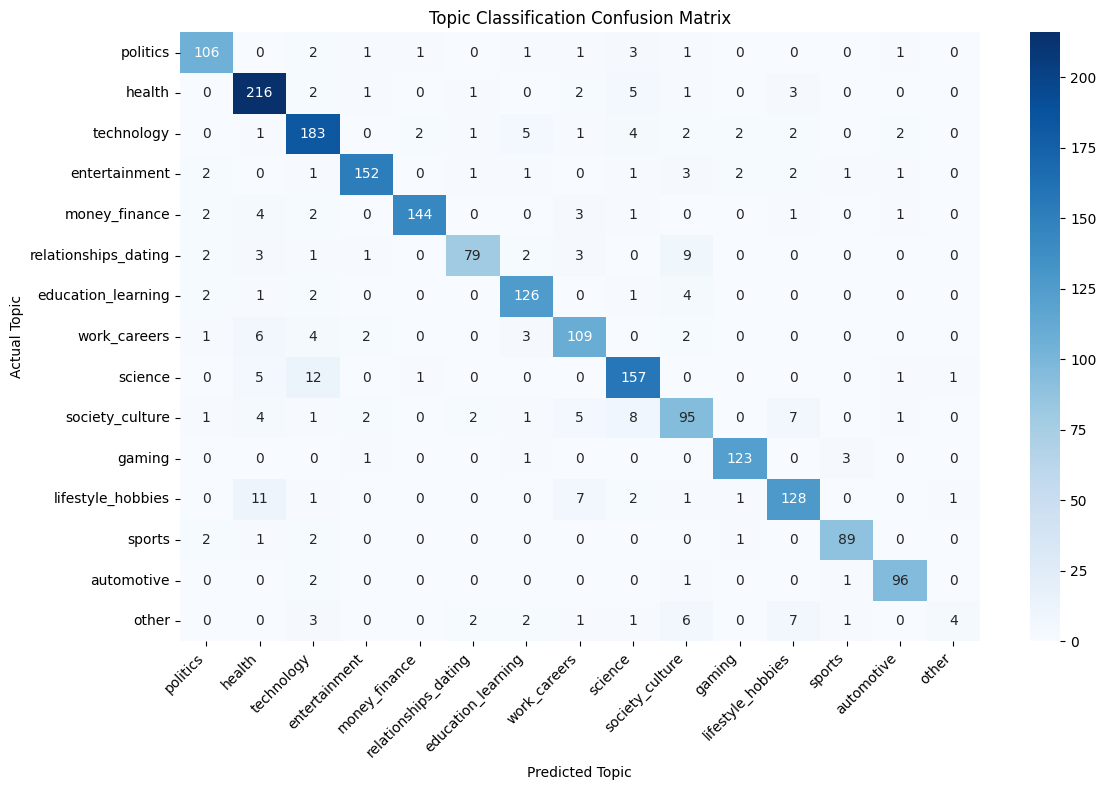

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=topics, yticklabels=topics)

plt.ylabel('Actual Topic')
plt.xlabel('Predicted Topic')
plt.title('Topic Classification Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [30]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall (weighted):    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 (weighted):        {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 (macro):           {f1_score(y_test, y_pred, average='macro'):.4f}")

Accuracy:  0.8828
Precision (weighted): 0.8819
Recall (weighted):    0.8828
F1 (weighted):        0.8795
F1 (macro):           0.8458


## TF-IDF Feature Representation

A common improvement over raw Bag-of-Words is **TF-IDF** (Term Frequency–Inverse Document Frequency).

TF-IDF reduces the influence of extremely common words and gives more importance to terms that are distinctive for specific documents or classes.

This often works better than raw word counts in text classification tasks, especially when combined with linear models such as Logistic Regression and Support Vector Machines.

In [31]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

print("TF-IDF feature matrix shape:", X_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF feature matrix shape: (10232, 5673)
TF-IDF vocabulary size: 5673


To ensure a fair comparison with the previous baseline, we apply the same train/test split strategy to the TF-IDF representation.

In [32]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_tfidf.shape, y_train_tfidf.shape)
print(X_test_tfidf.shape, y_test_tfidf.shape)

(8185, 5673) (8185,)
(2047, 5673) (2047,)


## Logistic Regression with TF-IDF

Logistic Regression is one of the strongest traditional baselines for multiclass text classification.

It often performs better than Naive Bayes because it learns direct decision boundaries between classes instead of relying on stronger independence assumptions.

In [33]:
clf_lr = LogisticRegression(max_iter=2000, random_state=42)
clf_lr.fit(X_train_tfidf, y_train_tfidf)

y_pred_lr = clf_lr.predict(X_test_tfidf)

In [34]:
print(classification_report(y_test_tfidf, y_pred_lr, target_names=topics))

                      precision    recall  f1-score   support

            politics       0.93      0.87      0.90       117
              health       0.87      0.95      0.91       231
          technology       0.83      0.91      0.87       205
       entertainment       0.91      0.90      0.91       167
       money_finance       0.97      0.94      0.96       158
relationships_dating       0.92      0.88      0.90       100
  education_learning       0.91      0.96      0.93       136
        work_careers       0.86      0.89      0.87       127
             science       0.84      0.89      0.87       177
     society_culture       0.82      0.75      0.78       127
              gaming       0.95      0.98      0.97       128
   lifestyle_hobbies       0.87      0.85      0.86       152
              sports       0.97      0.93      0.95        95
          automotive       0.99      0.93      0.96       100
               other       0.75      0.11      0.19        27

      

In [35]:
print(f"Accuracy:  {accuracy_score(y_test_tfidf, y_pred_lr):.4f}")
print(f"Precision (weighted): {precision_score(y_test_tfidf, y_pred_lr, average='weighted'):.4f}")
print(f"Recall (weighted):    {recall_score(y_test_tfidf, y_pred_lr, average='weighted'):.4f}")
print(f"F1 (weighted):        {f1_score(y_test_tfidf, y_pred_lr, average='weighted'):.4f}")
print(f"F1 (macro):           {f1_score(y_test_tfidf, y_pred_lr, average='macro'):.4f}")

Accuracy:  0.8935
Precision (weighted): 0.8933
Recall (weighted):    0.8935
F1 (weighted):        0.8895
F1 (macro):           0.8543


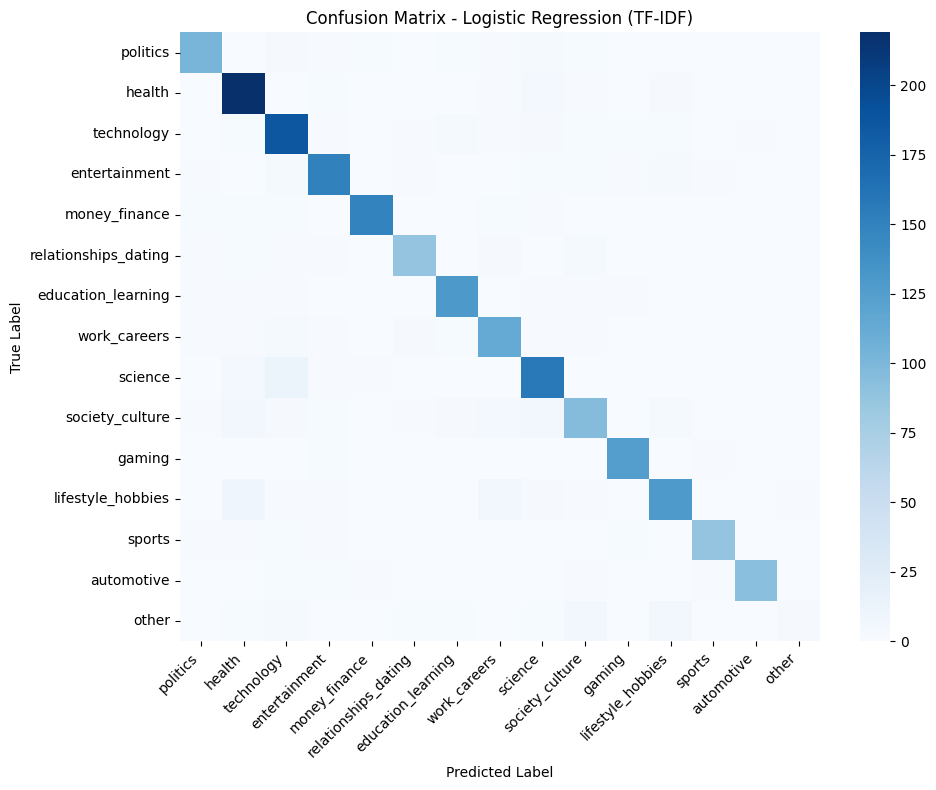

In [36]:
cm_lr = confusion_matrix(y_test_tfidf, y_pred_lr)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_lr, annot=False, cmap="Blues", fmt="d",
            xticklabels=topics, yticklabels=topics)
plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Linear SVM with TF-IDF

Linear Support Vector Machines are another very strong option for sparse text classification.

They often perform extremely well on high-dimensional text features such as TF-IDF, especially when the classes are separable through informative lexical patterns.

In [37]:
clf_svm = LinearSVC(random_state=42)
clf_svm.fit(X_train_tfidf, y_train_tfidf)

y_pred_svm = clf_svm.predict(X_test_tfidf)

In [38]:
print(classification_report(y_test_tfidf, y_pred_svm, target_names=topics))

                      precision    recall  f1-score   support

            politics       0.90      0.89      0.89       117
              health       0.87      0.94      0.91       231
          technology       0.86      0.89      0.88       205
       entertainment       0.92      0.93      0.93       167
       money_finance       0.96      0.96      0.96       158
relationships_dating       0.97      0.92      0.94       100
  education_learning       0.92      0.96      0.94       136
        work_careers       0.87      0.92      0.90       127
             science       0.85      0.88      0.87       177
     society_culture       0.84      0.72      0.78       127
              gaming       0.95      0.99      0.97       128
   lifestyle_hobbies       0.90      0.85      0.87       152
              sports       0.96      0.96      0.96        95
          automotive       0.96      0.95      0.95       100
               other       0.60      0.22      0.32        27

      

In [39]:
print(f"Accuracy:  {accuracy_score(y_test_tfidf, y_pred_svm):.4f}")
print(f"Precision (weighted): {precision_score(y_test_tfidf, y_pred_svm, average='weighted'):.4f}")
print(f"Recall (weighted):    {recall_score(y_test_tfidf, y_pred_svm, average='weighted'):.4f}")
print(f"F1 (weighted):        {f1_score(y_test_tfidf, y_pred_svm, average='weighted'):.4f}")
print(f"F1 (macro):           {f1_score(y_test_tfidf, y_pred_svm, average='macro'):.4f}")

Accuracy:  0.9018
Precision (weighted): 0.8994
Recall (weighted):    0.9018
F1 (weighted):        0.8988
F1 (macro):           0.8710


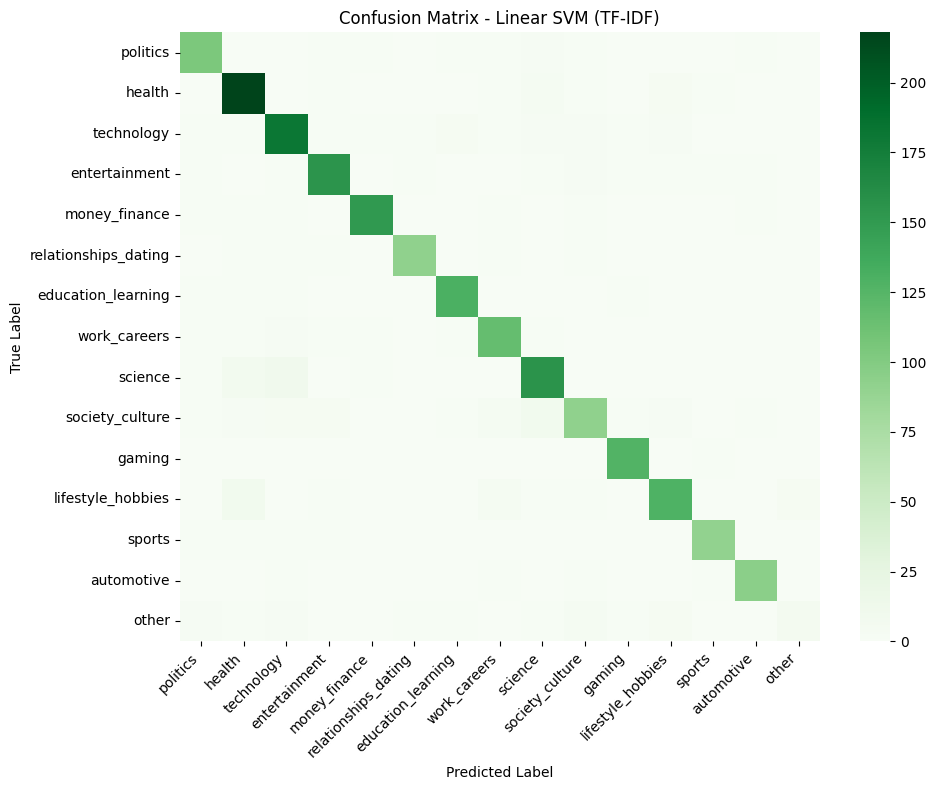

In [40]:
cm_svm = confusion_matrix(y_test_tfidf, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=False, cmap="Greens", fmt="d",
            xticklabels=topics, yticklabels=topics)
plt.title("Confusion Matrix - Linear SVM (TF-IDF)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Comparison

To compare the different approaches more clearly, we summarize the main evaluation metrics in a single table.

This makes it easier to identify whether TF-IDF improves over Bag-of-Words, and whether Logistic Regression or Linear SVM outperform the Naive Bayes baseline.

In [41]:
results = pd.DataFrame([
    {
        "Model": "Naive Bayes (BoW)",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_weighted": precision_score(y_test, y_pred, average="weighted"),
        "Recall_weighted": recall_score(y_test, y_pred, average="weighted"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "F1_macro": f1_score(y_test, y_pred, average="macro")
    },
    {
        "Model": "Logistic Regression (TF-IDF)",
        "Accuracy": accuracy_score(y_test_tfidf, y_pred_lr),
        "Precision_weighted": precision_score(y_test_tfidf, y_pred_lr, average="weighted"),
        "Recall_weighted": recall_score(y_test_tfidf, y_pred_lr, average="weighted"),
        "F1_weighted": f1_score(y_test_tfidf, y_pred_lr, average="weighted"),
        "F1_macro": f1_score(y_test_tfidf, y_pred_lr, average="macro")
    },
    {
        "Model": "Linear SVM (TF-IDF)",
        "Accuracy": accuracy_score(y_test_tfidf, y_pred_svm),
        "Precision_weighted": precision_score(y_test_tfidf, y_pred_svm, average="weighted"),
        "Recall_weighted": recall_score(y_test_tfidf, y_pred_svm, average="weighted"),
        "F1_weighted": f1_score(y_test_tfidf, y_pred_svm, average="weighted"),
        "F1_macro": f1_score(y_test_tfidf, y_pred_svm, average="macro")
    }
])

results = results.sort_values(by="F1_macro", ascending=False)
results

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro
2,Linear SVM (TF-IDF),0.901808,0.899386,0.901808,0.898831,0.871045
1,Logistic Regression (TF-IDF),0.893503,0.893281,0.893503,0.889514,0.854259
0,Naive Bayes (BoW),0.882755,0.881928,0.882755,0.879457,0.845761


In [42]:
results_rounded = results.copy()
metric_cols = ["Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted", "F1_macro"]
results_rounded[metric_cols] = results_rounded[metric_cols].round(4)

results_rounded

,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F1_macro
2,Linear SVM (TF-IDF),0.9018,0.8994,0.9018,0.8988,0.8710
1,Logistic Regression (TF-IDF),0.8935,0.8933,0.8935,0.8895,0.8543
0,Naive Bayes (BoW),0.8828,0.8819,0.8828,0.8795,0.8458


### Note on the Comparison Setup (might do later)

At this stage, the comparison includes changes in both the feature representation and the classifier.  
This means that if performance improves, the gain cannot yet be attributed exclusively to TF-IDF or exclusively to the classifier change.

To isolate these effects more clearly, later experiments should compare:

- the same classifier with different feature representations;
- different classifiers with the same feature representation.

This will make it possible to determine whether the main improvements come from TF-IDF weighting, from the classifier choice, or from the combination of both.